Starting simulation...
Simulation progress: 0.0%
Simulation progress: 10.0%
Simulation progress: 20.0%
Simulation progress: 30.0%
Simulation progress: 40.0%
Simulation progress: 50.0%
Simulation progress: 60.0%
Simulation progress: 70.0%
Simulation progress: 80.0%
Simulation progress: 90.0%
Simulation finished.

--- Performance Comparison ---
EKF RMSE x1 (Position): 0.0000
EKF RMSE x2 (Velocity): 0.0060
PF  RMSE x1 (Position): 0.0138
PF  RMSE x2 (Velocity): 0.0078


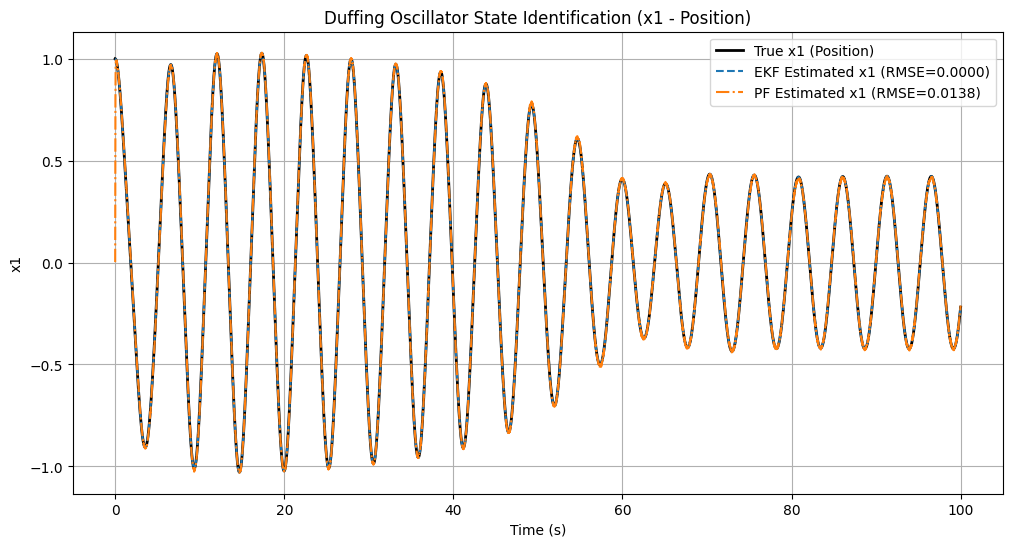

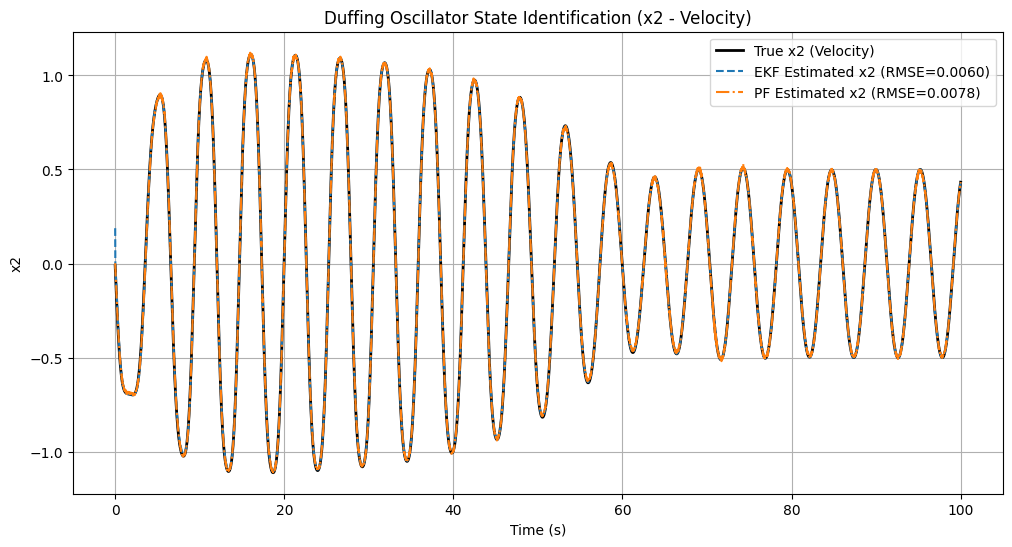

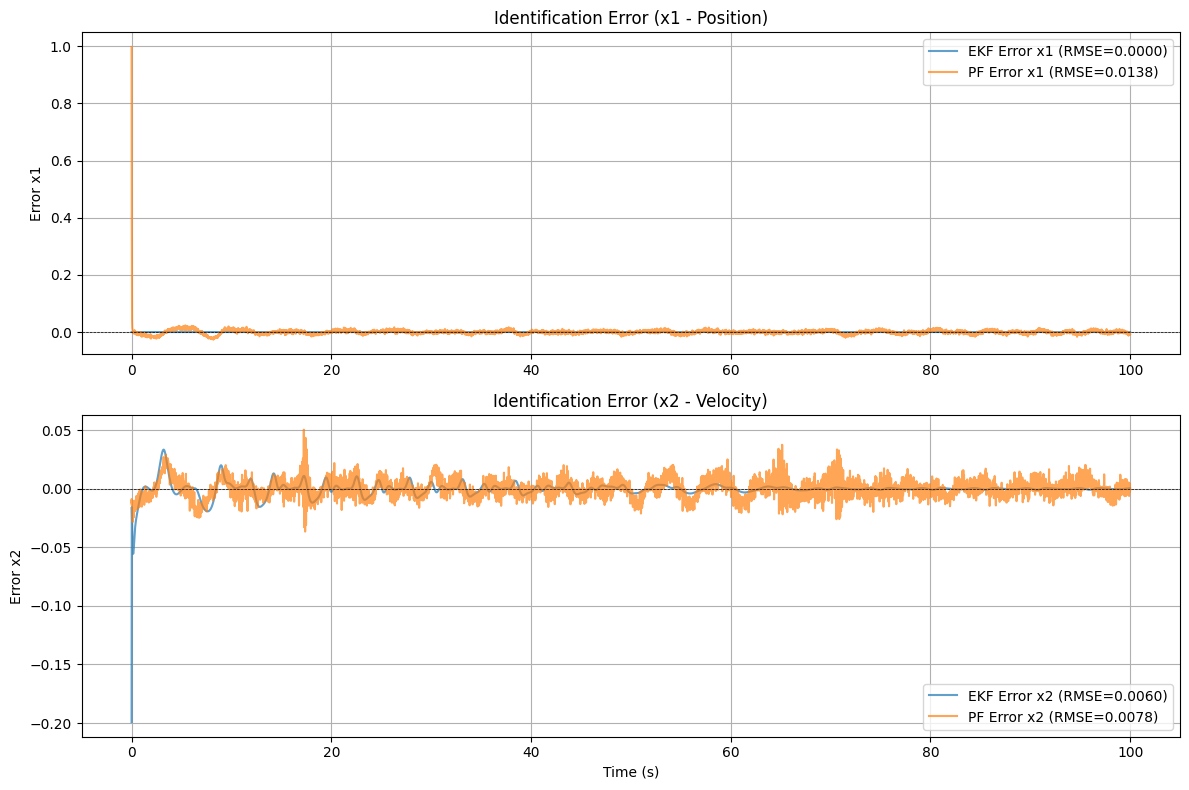

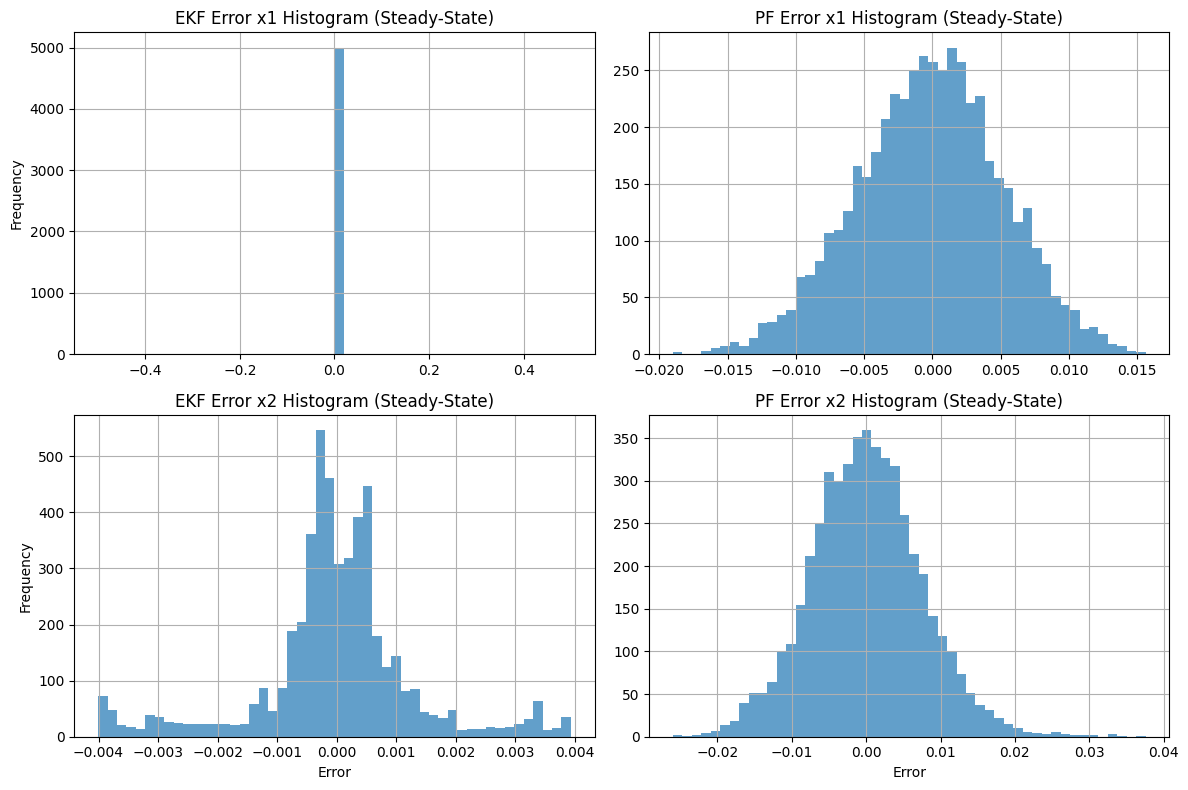

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the True Nonlinear System (Duffing Oscillator) ---
class DuffingOscillator:
    def __init__(self, alpha, beta, delta, gamma, omega, Ts):
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.gamma = gamma
        self.omega = omega
        self.Ts = Ts  # Sampling time
        self.x1 = 0.0 # Initial position
        self.x2 = 0.0 # Initial velocity

    def reset(self, x1_0=0.0, x2_0=0.0):
        self.x1 = x1_0
        self.x2 = x2_0

    def step(self, u_k):
        # Continuous dynamics: x1_dot = x2
        #                     x2_dot = -delta*x2 - alpha*x1 - beta*x1^3 + gamma*u
        # Euler discretization:
        x1_k = self.x1
        x2_k = self.x2
        x1_kp1 = x1_k + self.Ts * x2_k
        x2_kp1 = x2_k + self.Ts * (-self.delta * x2_k - self.alpha * x1_k - self.beta * x1_k**3 + self.gamma * u_k)
        self.x1 = x1_kp1
        self.x2 = x2_kp1
        return x1_kp1 # Output is position

# --- 2. Define the RHONN with EKF Training ---
class RHONN_EKF_Ident:
    # ... (Keep the EKF class exactly as it was in the previous corrected code) ...
    def __init__(self, n_states, n_inputs, Li_list, beta_nn=1.0, Q_init=1e-2, R_init=1e-1, P_init=1.0):
        self.n_states = n_states
        self.n_inputs = n_inputs
        self.beta_nn = beta_nn
        self.Li_list = Li_list
        self.weights = []
        self.P = []
        self.Q = []
        self.R = []
        for i in range(n_states):
            Li = self.Li_list[i]
            self.weights.append(np.random.randn(Li) * 0.1)
            self.P.append(np.eye(Li) * P_init)
            self.Q.append(np.eye(Li) * Q_init)
            self.R.append(np.array([R_init]))
        self.x_hat = np.zeros(n_states)

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-self.beta_nn * x))

    def construct_z_vector(self, x_est, u):
        if self.n_states != 2 or self.n_inputs != 1:
            raise NotImplementedError("This z vector construction is for n_states=2, n_inputs=1")
        S_x1 = self.sigmoid(x_est[0])
        S_x2 = self.sigmoid(x_est[1])
        S_u = self.sigmoid(u)
        S_x1_x2 = S_x1 * S_x2
        S_x1_u = S_x1 * S_u
        S_x2_u = S_x2 * S_u
        S_bias = self.sigmoid(1.0)
        z = np.array([S_x1, S_x2, S_u, S_x1_x2, S_x1_u, S_x2_u, S_bias])
        return z

    def predict_state(self, u_k):
        x_hat_pred = np.zeros(self.n_states)
        for i in range(self.n_states):
            z_i = self.construct_z_vector(self.x_hat, u_k)
            if len(z_i) != len(self.weights[i]):
                 raise ValueError(f"Dimension mismatch: z_i ({len(z_i)}) vs weights[{i}] ({len(self.weights[i])})")
            x_hat_pred[i] = np.dot(self.weights[i], z_i)
        return x_hat_pred

    def update_weights_and_state(self, chi_measured, u_k):
        x_hat_pred = self.predict_state(u_k)
        for i in range(self.n_states):
            chi_i_measured = chi_measured[i]
            z_i = self.construct_z_vector(x_hat_pred, u_k) # Use predicted state for H calc
            if len(z_i) != len(self.weights[i]):
                 raise ValueError(f"Dimension mismatch (update): z_i ({len(z_i)}) vs weights[{i}] ({len(self.weights[i])})")

            H_i = z_i
            P_pred = self.P[i] + self.Q[i]
            H_i = H_i.reshape(-1, 1)
            M_i = self.R[i][0] + np.dot(H_i.T, np.dot(P_pred, H_i))[0, 0]
            if M_i > 1e-10:
                K_i = np.dot(P_pred, H_i).flatten() / M_i
            else:
                K_i = np.zeros_like(self.weights[i])
            e_i = chi_i_measured - x_hat_pred[i]
            self.weights[i] += K_i * e_i
            P_update = P_pred - np.outer(K_i, np.dot(H_i.T, P_pred)).reshape(P_pred.shape)
            self.P[i] = P_update

        # Series-Parallel: Use measured output for the first state (output)
        self.x_hat[0] = chi_measured[0] # Measured output
        self.x_hat[1:] = x_hat_pred[1:] # Use predicted for hidden/internal states

# --- 3. Define the RHONN with Improved Particle Filter (PF) Training ---
class RHONN_PF_Ident:
    def __init__(self, n_states, n_inputs, Li_list, beta_nn=1.0, n_particles=100, Q_std_init=0.1, R_std=0.1):
        """
        n_states: Number of system states to identify (e.g., 2 for Duffing)
        n_inputs: Number of system inputs (e.g., 1 for Duffing)
        Li_list: List of integers, Li_list[i] = number of weights for neuron i
        beta_nn: Sigmoid steepness parameter (Eq. 5)
        n_particles: Number of particles for the PF
        Q_std_init, R_std: Noise standard deviations.
                           Q_std: Std dev for process noise on weights (random walk).
                           R_std: Std dev for measurement noise (used for likelihood).
        """
        self.n_states = n_states
        self.n_inputs = n_inputs
        self.beta_nn = beta_nn
        self.n_particles = n_particles
        self.Li_list = Li_list
        self.Q_std = Q_std_init # Process noise std dev for weights
        self.R_std = R_std      # Measurement noise std dev
        self.R_var = R_std**2   # Measurement noise variance

        # --- Initialize particles for weights for each neuron ---
        self.particles = [] # List of particle arrays for each neuron (n_particles x Li)
        self.weights_pf = [] # List of particle weights (n_particles,) for each neuron (importance weights)

        for i in range(n_states):
            Li = self.Li_list[i]
            # Random initial particles for weights (n_particles x Li)
            particles_i = np.random.randn(n_particles, Li) * 0.1
            self.particles.append(particles_i)
            # Initialize uniform weights for particles
            weights_pf_i = np.ones(n_particles) / n_particles
            self.weights_pf.append(weights_pf_i)

        self.x_hat = np.zeros(n_states) # Internal state estimate (e.g., mean of particles)

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-self.beta_nn * x))

    def construct_z_vector(self, x_est, u):
        """ Identical to EKF version """
        if self.n_states != 2 or self.n_inputs != 1:
            raise NotImplementedError("This z vector construction is for n_states=2, n_inputs=1")
        S_x1 = self.sigmoid(x_est[0])
        S_x2 = self.sigmoid(x_est[1])
        S_u = self.sigmoid(u)
        S_x1_x2 = S_x1 * S_x2
        S_x1_u = S_x1 * S_u
        S_x2_u = S_x2 * S_u
        S_bias = self.sigmoid(1.0)
        z = np.array([S_x1, S_x2, S_u, S_x1_x2, S_x1_u, S_x2_u, S_bias])
        return z

    def predict_state_from_particles(self, particles_i, x_state, u_k):
        """ Predict state for a single neuron using a set of particles (weights) """
        z_i = self.construct_z_vector(x_state, u_k)
        x_pred_particles = np.dot(particles_i, z_i) # (n_particles x Li) * (Li,) -> (n_particles,)
        return x_pred_particles

    def update_weights_and_state(self, chi_measured, u_k):
        """
        Performs one Particle Filter step.
        chi_measured: np.array of measured/true plant states [chi_1, chi_2, ...]
        u_k: Input at time k
        """
        # --- 1. Prediction Step for Particles (Weight Dynamics) ---
        # Assume random walk model: w_i(k+1) = w_i(k) + q_i(k), q_i ~ N(0, Q_std^2 * I)
        # Sample process noise for each particle and each weight dimension
        for i in range(self.n_states):
            Li = self.Li_list[i]
            # Generate noise: (n_particles, Li)
            noise_process = np.random.randn(self.n_particles, Li) * self.Q_std
            # Update particles: w_i(k+1|k) = w_i(k|k) + noise
            self.particles[i] += noise_process

        # --- 2. Series-Parallel Correction for Prediction ---
        # Use the measured output state (chi_measured[0]) immediately for constructing z
        x_state_for_z = np.copy(self.x_hat) # Start with previous estimate
        x_state_for_z[0] = chi_measured[0]  # Override x1 with measured value

        # --- 3. Predict state using current particles and the updated x_state_for_z ---
        x_hat_pred_particles = np.zeros((self.n_particles, self.n_states))
        for i in range(self.n_states):
            x_hat_pred_particles[:, i] = self.predict_state_from_particles(self.particles[i], x_state_for_z, u_k)

        # --- 4. Update particle weights (Importance Sampling) ---
        for i in range(self.n_states):
            chi_i_measured = chi_measured[i]
            x_pred_particles_i = x_hat_pred_particles[:, i] # Predictions from all particles for state i

            # Compute importance weights (Gaussian likelihood of measurement)
            innovation_i = chi_i_measured - x_pred_particles_i # (n_particles,)
            # Log-likelihood for numerical stability
            log_likelihood_i = -0.5 * (innovation_i**2) / self.R_var
            # Normalize log-likelihood to prevent underflow
            log_likelihood_i -= np.max(log_likelihood_i)
            likelihood_i = np.exp(log_likelihood_i)
            # Update weights: w_i^j = w_i^{j-} * likelihood_i^j
            self.weights_pf[i] *= likelihood_i
            # Normalize weights
            weight_sum = np.sum(self.weights_pf[i])
            if weight_sum > 1e-10:
                self.weights_pf[i] /= weight_sum
            else:
                # If all weights collapse, reset to uniform (resample?)
                print(f"Warning: Weight collapse in neuron {i} at step. Resetting weights.")
                self.weights_pf[i] = np.ones(self.n_particles) / self.n_particles # Reset if needed

            # --- 5. Resampling Step (prevent degeneracy) ---
            # Use systematic resampling for better performance
            self.resample_systematic(i)
            # Alternative: Simple multinomial resampling (commented out)
            # self.resample_multinomial(i)

        # --- 6. Update the internal state estimate (e.g., mean of particles) ---
        # Use the particle predictions made with the *correct* z vector (using measured x1)
        for i in range(self.n_states):
             self.x_hat[i] = np.mean(x_hat_pred_particles[:, i])

    def resample_systematic(self, neuron_index):
        """ Systematic Resampling """
        weights = self.weights_pf[neuron_index]
        particles = self.particles[neuron_index]

        # Normalize weights (should already be, but just in case)
        weights /= np.sum(weights)

        N = self.n_particles
        # Generate one random offset
        u = np.random.uniform(0, 1/N)
        # Cumulative sum of weights
        cw = np.cumsum(weights)
        # Indices for resampled particles
        indices = []
        i, j = 0, 0
        while i < N:
            while cw[j] < u + i/N:
                j += 1
            indices.append(j)
            i += 1
        # Update particles and reset weights
        self.particles[neuron_index] = particles[indices]
        self.weights_pf[neuron_index] = np.ones(N) / N

    def resample_multinomial(self, neuron_index):
        """ Simple Multinomial Resampling (Alternative) """
        weights = self.weights_pf[neuron_index]
        particles = self.particles[neuron_index]
        indices = np.random.choice(np.arange(self.n_particles), size=self.n_particles, p=weights)
        self.particles[neuron_index] = particles[indices]
        self.weights_pf[neuron_index] = np.ones(self.n_particles) / self.n_particles


# --- 4. Simulation Parameters ---
# Duffing Oscillator Parameters
alpha_duffing = 0.5
beta_duffing = 1.0
delta_duffing = 0.3
gamma_duffing = 0.37
omega_duffing = 1.2

# Simulation settings
Ts = 0.01
t_final = 100.0
num_steps = int(t_final / Ts)

# --- 5. Initialize System and Identifiers ---
plant = DuffingOscillator(alpha_duffing, beta_duffing, delta_duffing, gamma_duffing, omega_duffing, Ts)
x1_0_true = 1.0
x2_0_true = 0.0
plant.reset(x1_0_true, x2_0_true)

# Common RHONN settings
n_states_plant = 2
n_inputs_plant = 1
Li_per_neuron = 7
Li_list_rhonn = [Li_per_neuron] * n_states_plant

# Create the EKF identifier
identifier_ekf = RHONN_EKF_Ident(n_states_plant, n_inputs_plant, Li_list_rhonn,
                                 beta_nn=1.0, Q_init=1e-4, R_init=1e-2, P_init=1.0)

# Create the PF identifier (using the improved version)
identifier_pf = RHONN_PF_Ident(n_states_plant, n_inputs_plant, Li_list_rhonn,
                               beta_nn=1.0, n_particles=800, Q_std_init=0.05, R_std=np.sqrt(1e-2))

# --- 6. Run Simulation ---
t_history = []
x1_true_history = []
x2_true_history = []
u_history = []

# EKF histories
x1_est_ekf_history = []
x2_est_ekf_history = []

# PF histories
x1_est_pf_history = []
x2_est_pf_history = []

print("Starting simulation...")
for k in range(num_steps):
    t_k = k * Ts
    t_history.append(t_k)

    # --- 1. Generate Input ---
    u_k = np.cos(omega_duffing * t_k)
    u_history.append(u_k)

    # --- 2. Plant Step ---
    x1_k_true = plant.step(u_k)
    x2_k_true = plant.x2

    x1_true_history.append(x1_k_true)
    x2_true_history.append(x2_k_true)

    # --- 3. Identifier Updates (EKF & PF) ---
    chi_measured = np.array([x1_k_true, x2_k_true])

    # EKF Update
    identifier_ekf.update_weights_and_state(chi_measured, u_k)
    x1_est_ekf_history.append(identifier_ekf.x_hat[0])
    x2_est_ekf_history.append(identifier_ekf.x_hat[1])

    # PF Update
    identifier_pf.update_weights_and_state(chi_measured, u_k)
    x1_est_pf_history.append(identifier_pf.x_hat[0])
    x2_est_pf_history.append(identifier_pf.x_hat[1])

    if k % (num_steps // 10) == 0:
        print(f"Simulation progress: {k/num_steps*100:.1f}%")

print("Simulation finished.")

# --- 7. Plot Results ---
t_history = np.array(t_history)
x1_true_history = np.array(x1_true_history)
x2_true_history = np.array(x2_true_history)
x1_est_ekf_history = np.array(x1_est_ekf_history)
x2_est_ekf_history = np.array(x2_est_ekf_history)
x1_est_pf_history = np.array(x1_est_pf_history)
x2_est_pf_history = np.array(x2_est_pf_history)

x1_error_ekf = x1_true_history - x1_est_ekf_history
x2_error_ekf = x2_true_history - x2_est_ekf_history
x1_error_pf = x1_true_history - x1_est_pf_history
x2_error_pf = x2_true_history - x2_est_pf_history

rmse_x1_ekf = np.sqrt(np.mean(x1_error_ekf**2))
rmse_x2_ekf = np.sqrt(np.mean(x2_error_ekf**2))
rmse_x1_pf = np.sqrt(np.mean(x1_error_pf**2))
rmse_x2_pf = np.sqrt(np.mean(x2_error_pf**2))

print("\n--- Performance Comparison ---")
print(f"EKF RMSE x1 (Position): {rmse_x1_ekf:.4f}")
print(f"EKF RMSE x2 (Velocity): {rmse_x2_ekf:.4f}")
print(f"PF  RMSE x1 (Position): {rmse_x1_pf:.4f}")
print(f"PF  RMSE x2 (Velocity): {rmse_x2_pf:.4f}")

# --- 8. Plot Comparisons ---
# State x1 (Position)
plt.figure(figsize=(12, 6))
plt.plot(t_history, x1_true_history, label='True x1 (Position)', linewidth=2, color='black')
plt.plot(t_history, x1_est_ekf_history, '--', label=f'EKF Estimated x1 (RMSE={rmse_x1_ekf:.4f})', linewidth=1.5)
plt.plot(t_history, x1_est_pf_history, '-.', label=f'PF Estimated x1 (RMSE={rmse_x1_pf:.4f})', linewidth=1.5)
plt.ylabel('x1')
plt.xlabel('Time (s)')
plt.title('Duffing Oscillator State Identification (x1 - Position)')
plt.legend()
plt.grid(True)
plt.show()

# State x2 (Velocity) - This should now work better with the corrected PF
plt.figure(figsize=(12, 6))
plt.plot(t_history, x2_true_history, label='True x2 (Velocity)', linewidth=2, color='black')
plt.plot(t_history, x2_est_ekf_history, '--', label=f'EKF Estimated x2 (RMSE={rmse_x2_ekf:.4f})', linewidth=1.5)
plt.plot(t_history, x2_est_pf_history, '-.', label=f'PF Estimated x2 (RMSE={rmse_x2_pf:.4f})', linewidth=1.5)
plt.ylabel('x2')
plt.xlabel('Time (s)')
plt.title('Duffing Oscillator State Identification (x2 - Velocity)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Errors
fig2, axs2 = plt.subplots(2, 1, figsize=(12, 8))

axs2[0].plot(t_history, x1_error_ekf, label=f'EKF Error x1 (RMSE={rmse_x1_ekf:.4f})', alpha=0.7)
axs2[0].plot(t_history, x1_error_pf, label=f'PF Error x1 (RMSE={rmse_x1_pf:.4f})', alpha=0.7)
axs2[0].set_ylabel('Error x1')
axs2[0].set_title('Identification Error (x1 - Position)')
axs2[0].legend()
axs2[0].grid(True)
axs2[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

axs2[1].plot(t_history, x2_error_ekf, label=f'EKF Error x2 (RMSE={rmse_x2_ekf:.4f})', alpha=0.7)
axs2[1].plot(t_history, x2_error_pf, label=f'PF Error x2 (RMSE={rmse_x2_pf:.4f})', alpha=0.7)
axs2[1].set_ylabel('Error x2')
axs2[1].set_xlabel('Time (s)')
axs2[1].set_title('Identification Error (x2 - Velocity)')
axs2[1].legend()
axs2[1].grid(True)
axs2[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# --- 9. Plot Error Histograms (last 50% of simulation for steady-state analysis) ---
start_idx = len(t_history) // 2
if start_idx < len(t_history):
    x1_error_ekf_ss = x1_error_ekf[start_idx:]
    x2_error_ekf_ss = x2_error_ekf[start_idx:]
    x1_error_pf_ss = x1_error_pf[start_idx:]
    x2_error_pf_ss = x2_error_pf[start_idx:]

    fig3, axs3 = plt.subplots(2, 2, figsize=(12, 8))
    axs3[0, 0].hist(x1_error_ekf_ss, bins=50, alpha=0.7, label='EKF')
    axs3[0, 0].set_title('EKF Error x1 Histogram (Steady-State)')
    axs3[0, 0].set_ylabel('Frequency')
    axs3[0, 0].grid(True)

    axs3[0, 1].hist(x1_error_pf_ss, bins=50, alpha=0.7, label='PF')
    axs3[0, 1].set_title('PF Error x1 Histogram (Steady-State)')
    axs3[0, 1].grid(True)

    axs3[1, 0].hist(x2_error_ekf_ss, bins=50, alpha=0.7, label='EKF')
    axs3[1, 0].set_title('EKF Error x2 Histogram (Steady-State)')
    axs3[1, 0].set_ylabel('Frequency')
    axs3[1, 0].set_xlabel('Error')
    axs3[1, 0].grid(True)

    axs3[1, 1].hist(x2_error_pf_ss, bins=50, alpha=0.7, label='PF')
    axs3[1, 1].set_title('PF Error x2 Histogram (Steady-State)')
    axs3[1, 1].set_xlabel('Error')
    axs3[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data points to plot steady-state histograms.")


: 